In [4]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "data/raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

df_clean = df.copy()

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
print("Total Rows :", len(df_clean))
print("Unique Orders :", df_clean["Order Id"].nunique())
print("Unique Customers :", df_clean["Customer Id"].nunique())
print("Unique Products :", df_clean["Product Name"].nunique())
print("Total Revenue :", round(df_clean["Sales"].sum(),2))
print("Total Profit :", round(df_clean["Benefit per order"].sum(),2))

Total Rows : 180519
Unique Orders : 65752
Unique Customers : 20652
Unique Products : 118
Total Revenue : 36784735.01
Total Profit : 3966902.97


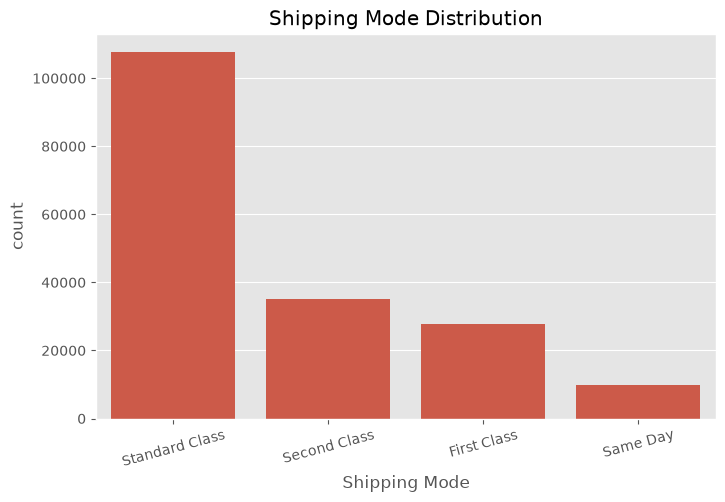

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Shipping Mode",
    order=df_clean["Shipping Mode"].value_counts().index
)

plt.title("Shipping Mode Distribution")
plt.xticks(rotation=15)
plt.show()

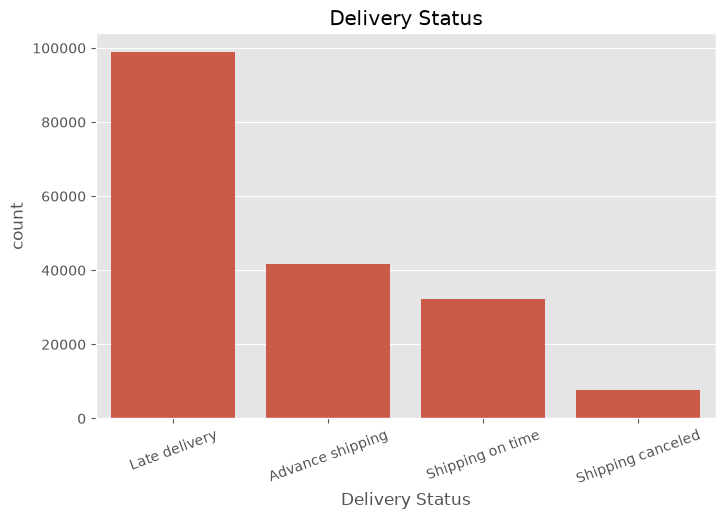

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Delivery Status",
    order=df_clean["Delivery Status"].value_counts().index
)

plt.title("Delivery Status")
plt.xticks(rotation=20)
plt.show()


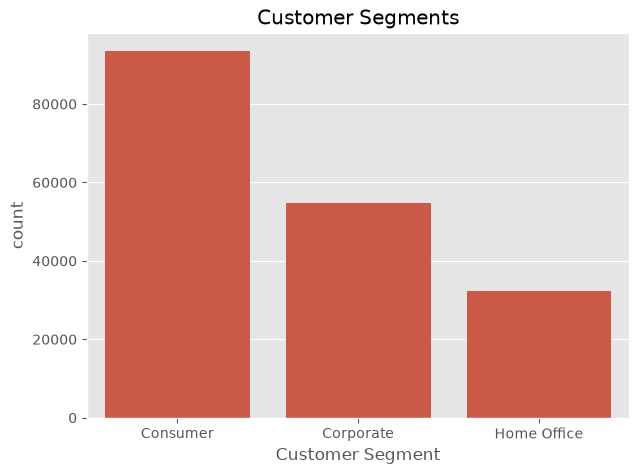

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Customer Segment",
    order=df_clean["Customer Segment"].value_counts().index
)

plt.title("Customer Segments")
plt.show()

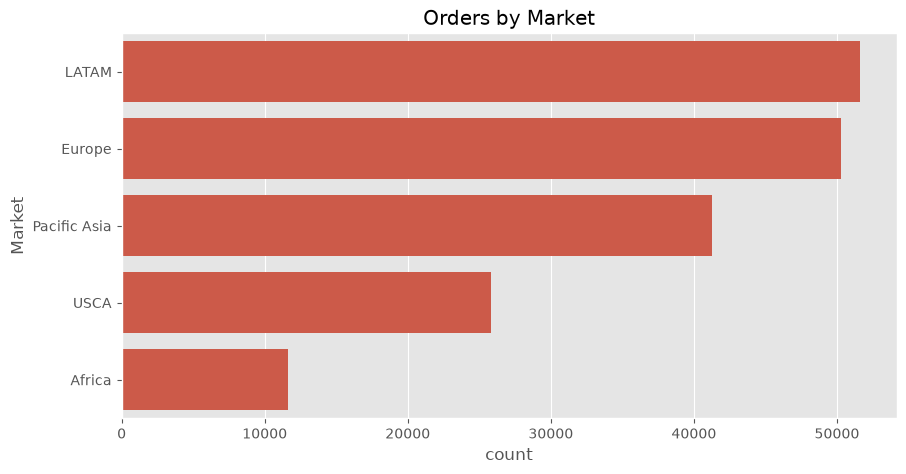

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    y="Market",
    order=df_clean["Market"].value_counts().index
)

plt.title("Orders by Market")
plt.show()

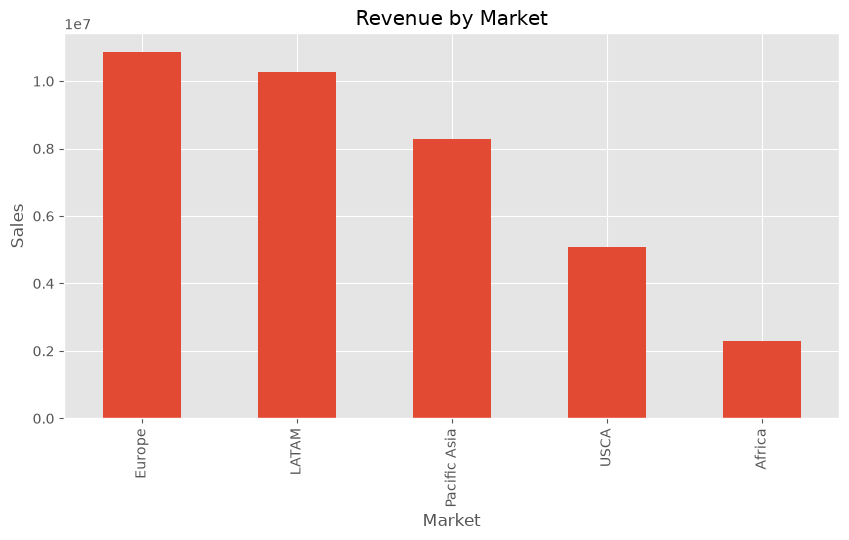

In [13]:
market_sales = (
    df_clean.groupby("Market")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

market_sales.plot(kind="bar")

plt.title("Revenue by Market")
plt.ylabel("Sales")

plt.show()

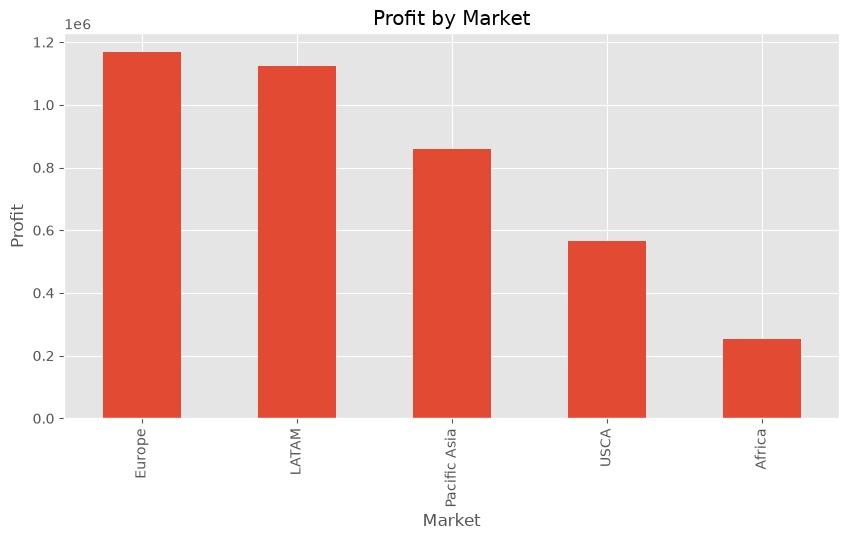

In [14]:
market_profit = (
    df_clean.groupby("Market")["Benefit per order"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

market_profit.plot(kind="bar")

plt.title("Profit by Market")
plt.ylabel("Profit")

plt.show()

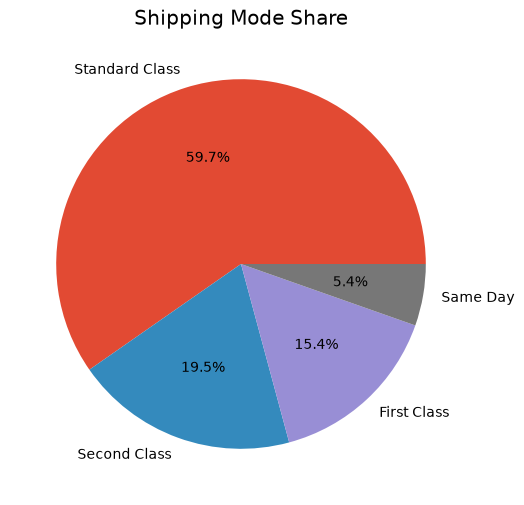

In [15]:
plt.figure(figsize=(8,6))

df_clean["Shipping Mode"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Shipping Mode Share")
plt.show()

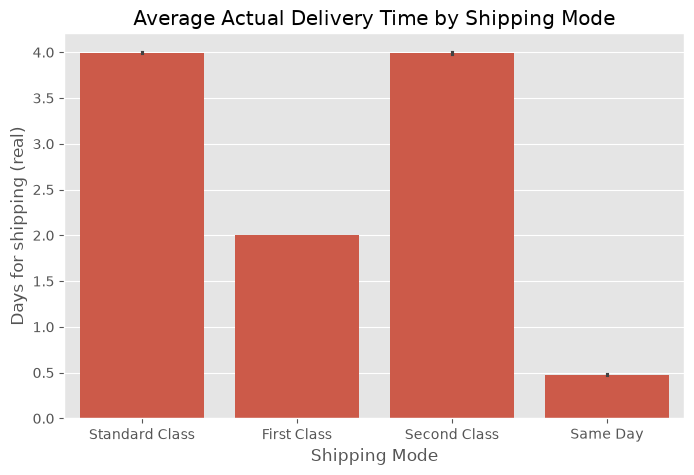

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Shipping Mode",
    y="Days for shipping (real)",
    estimator=np.mean
)

plt.title("Average Actual Delivery Time by Shipping Mode")
plt.show()

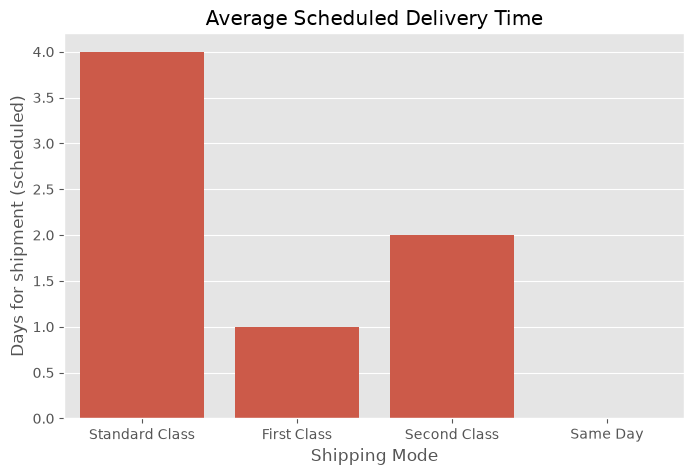

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Shipping Mode",
    y="Days for shipment (scheduled)",
    estimator=np.mean
)

plt.title("Average Scheduled Delivery Time")
plt.show()

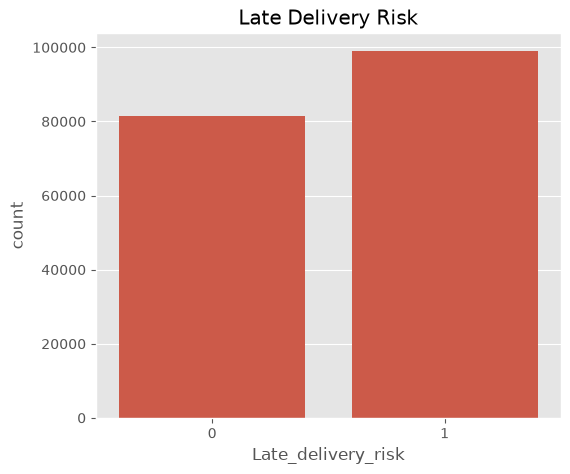

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_clean,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Risk")
plt.show()

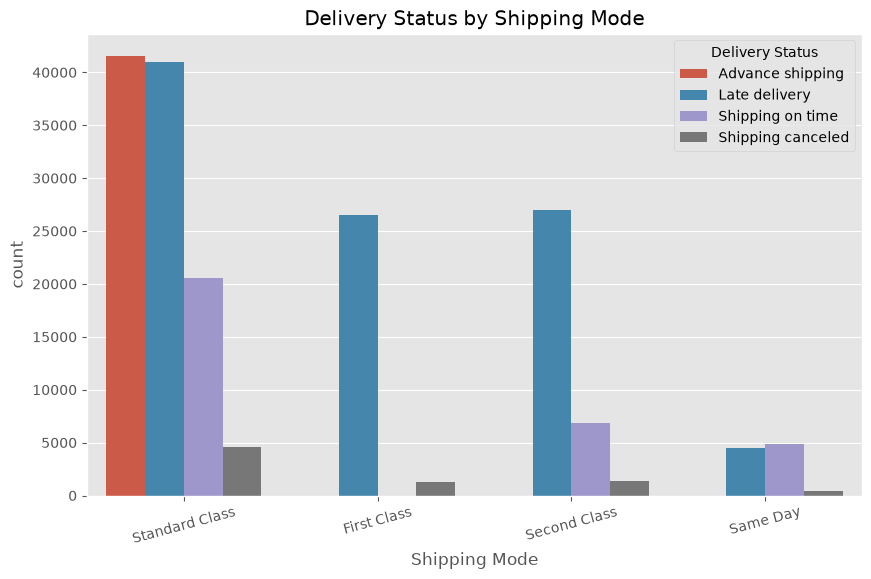

In [19]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    x="Shipping Mode",
    hue="Delivery Status"
)

plt.title("Delivery Status by Shipping Mode")
plt.xticks(rotation=15)
plt.show()

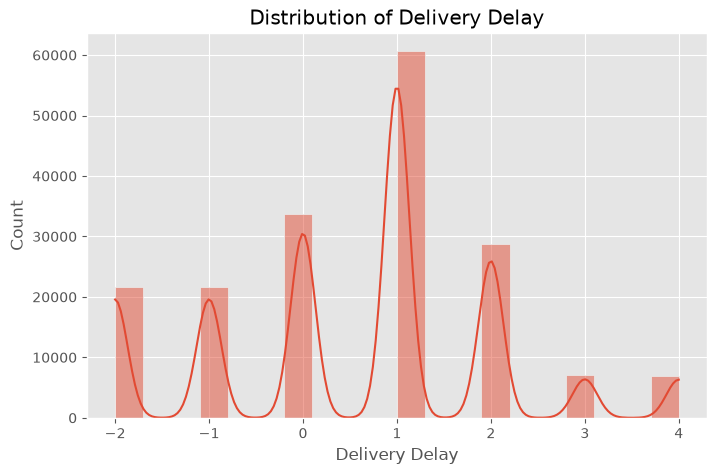

In [21]:
df_clean["Delivery Delay"] = (
    df_clean["Days for shipping (real)"] -
    df_clean["Days for shipment (scheduled)"]
)
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Delivery Delay"],
    bins=20,
    kde=True
)

plt.title("Distribution of Delivery Delay")
plt.show()

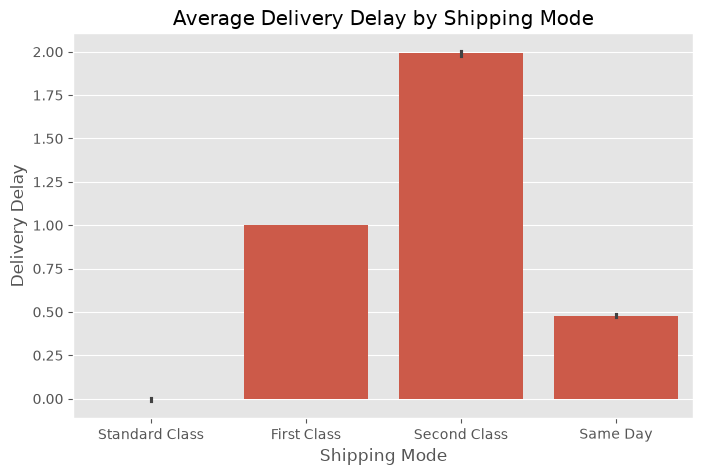

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Shipping Mode",
    y="Delivery Delay",
    estimator=np.mean
)

plt.title("Average Delivery Delay by Shipping Mode")
plt.show()

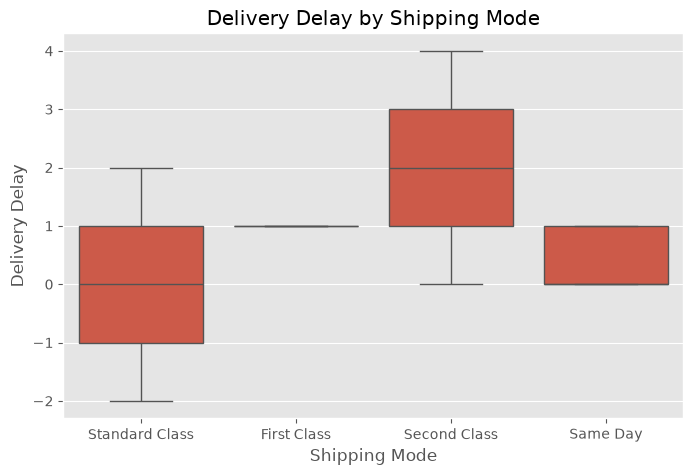

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Shipping Mode",
    y="Delivery Delay"
)

plt.title("Delivery Delay by Shipping Mode")
plt.show()

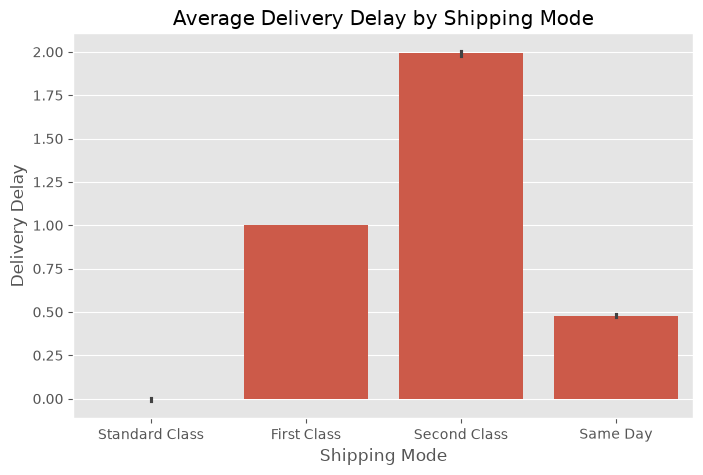

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="Shipping Mode",
    y="Delivery Delay",
    estimator=np.mean
)

plt.title("Average Delivery Delay by Shipping Mode")
plt.show()

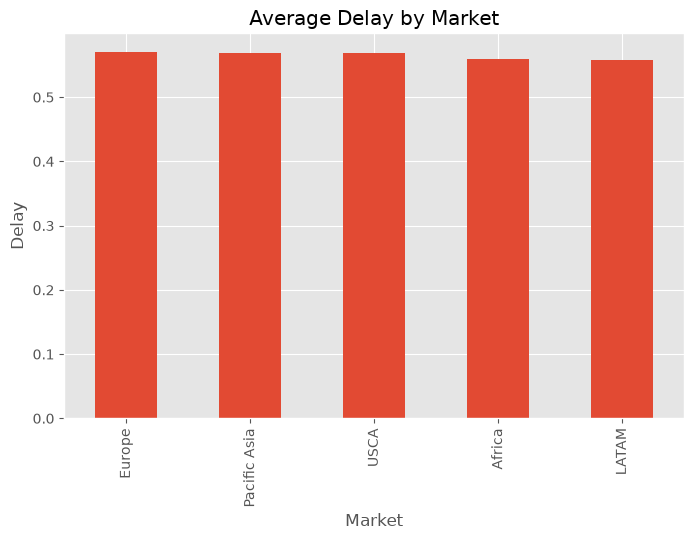

In [26]:
market_delay = (
    df_clean.groupby("Market")["Delivery Delay"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

market_delay.plot(kind="bar")

plt.title("Average Delay by Market")
plt.ylabel("Delay")
plt.show()

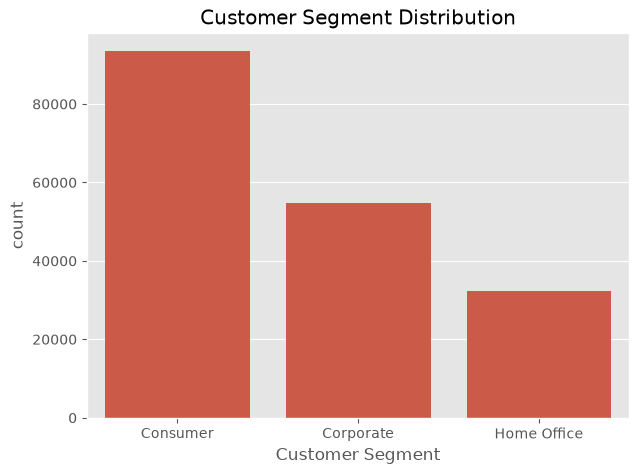

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Customer Segment",
    order=df_clean["Customer Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.show()

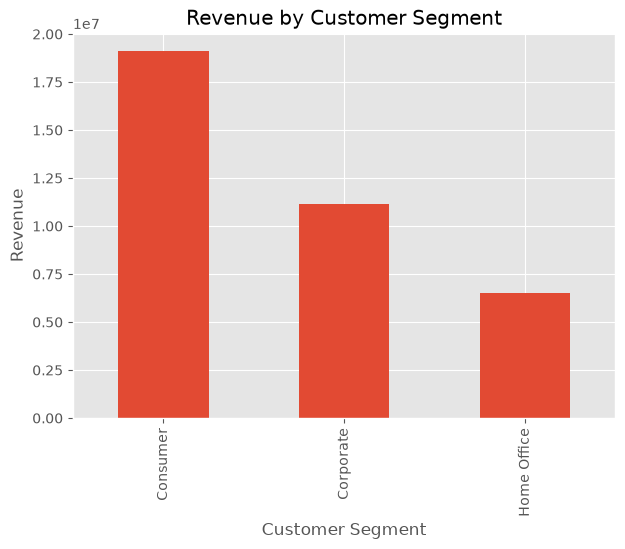

In [28]:
segment_sales = (
    df_clean.groupby("Customer Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))
segment_sales.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.show()

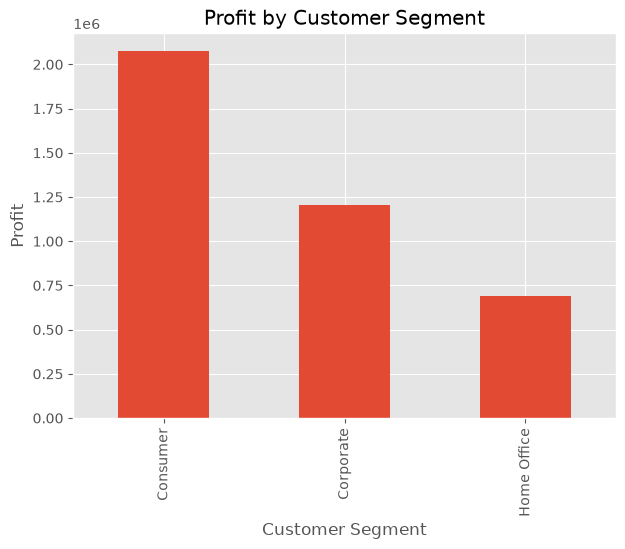

In [29]:
segment_profit = (
    df_clean.groupby("Customer Segment")["Benefit per order"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))
segment_profit.plot(kind="bar")

plt.title("Profit by Customer Segment")
plt.ylabel("Profit")
plt.show()

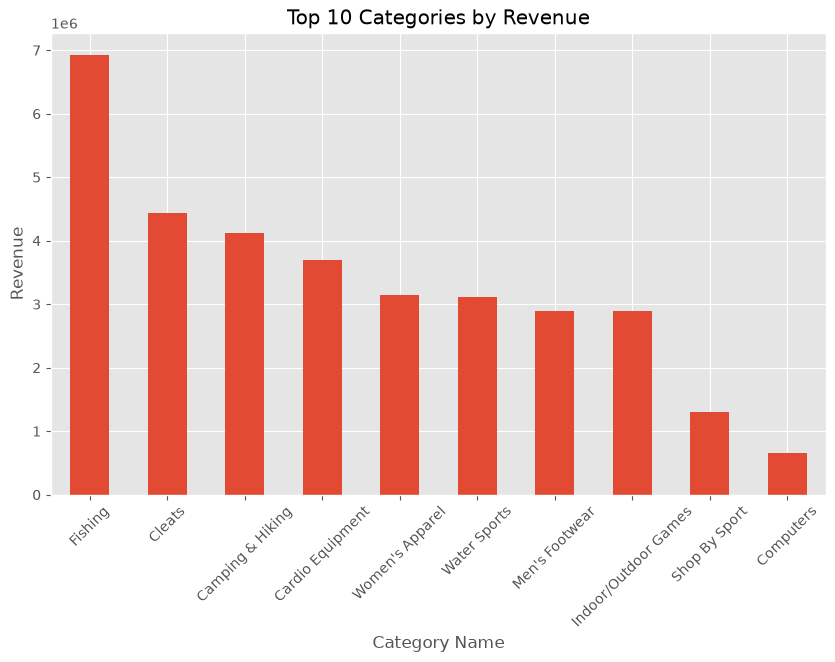

In [33]:
category_sales = (
    df_clean.groupby("Category Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

plt.title("Top 10 Categories by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

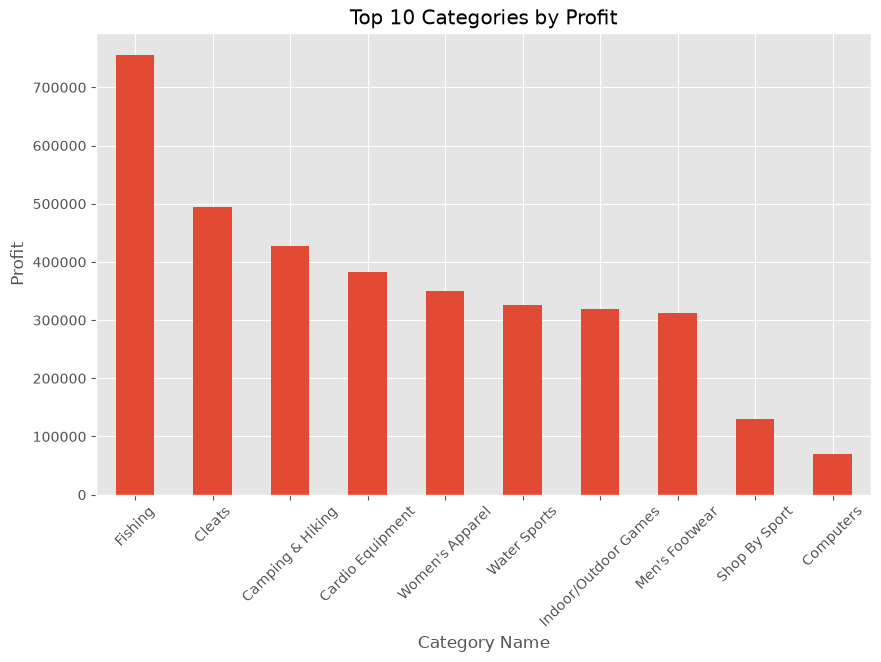

In [34]:
category_profit = (
    df_clean.groupby("Category Name")["Benefit per order"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

category_profit.plot(kind="bar")

plt.title("Top 10 Categories by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.show()

In [36]:
df_clean["order date (DateOrders)"] = pd.to_datetime(
    df_clean["order date (DateOrders)"]
)

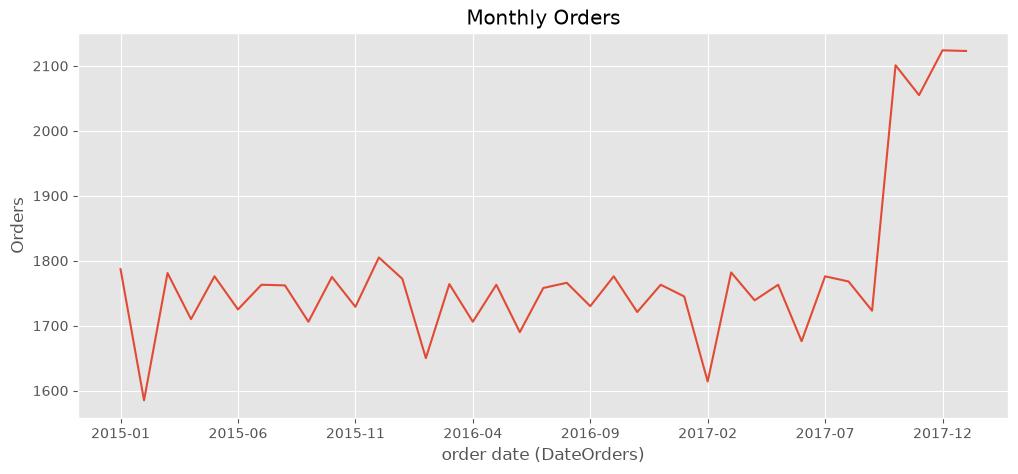

In [37]:
monthly_orders = (
    df_clean
    .groupby(df_clean["order date (DateOrders)"].dt.to_period("M"))
    ["Order Id"]
    .nunique()
)

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(12,5))

monthly_orders.plot()

plt.title("Monthly Orders")
plt.ylabel("Orders")

plt.show()

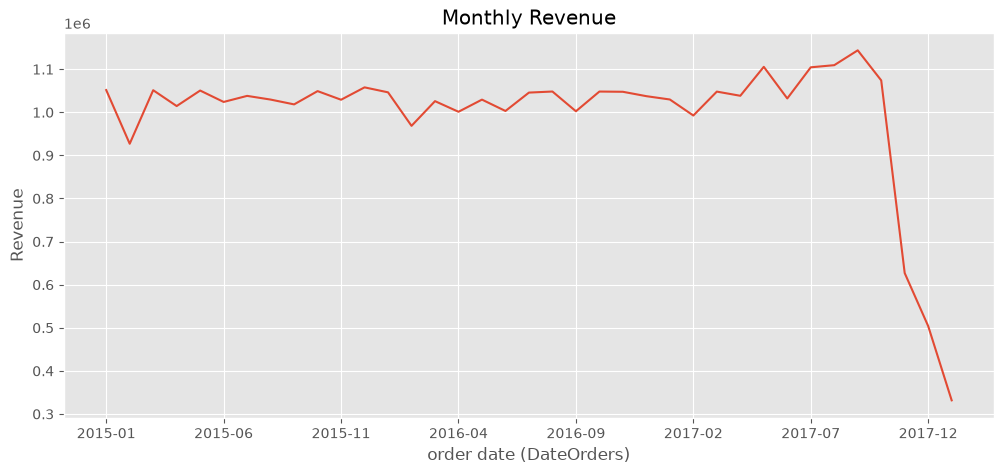

In [38]:
monthly_sales = (
    df_clean
    .groupby(df_clean["order date (DateOrders)"].dt.to_period("M"))
    ["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue")
plt.ylabel("Revenue")

plt.show()

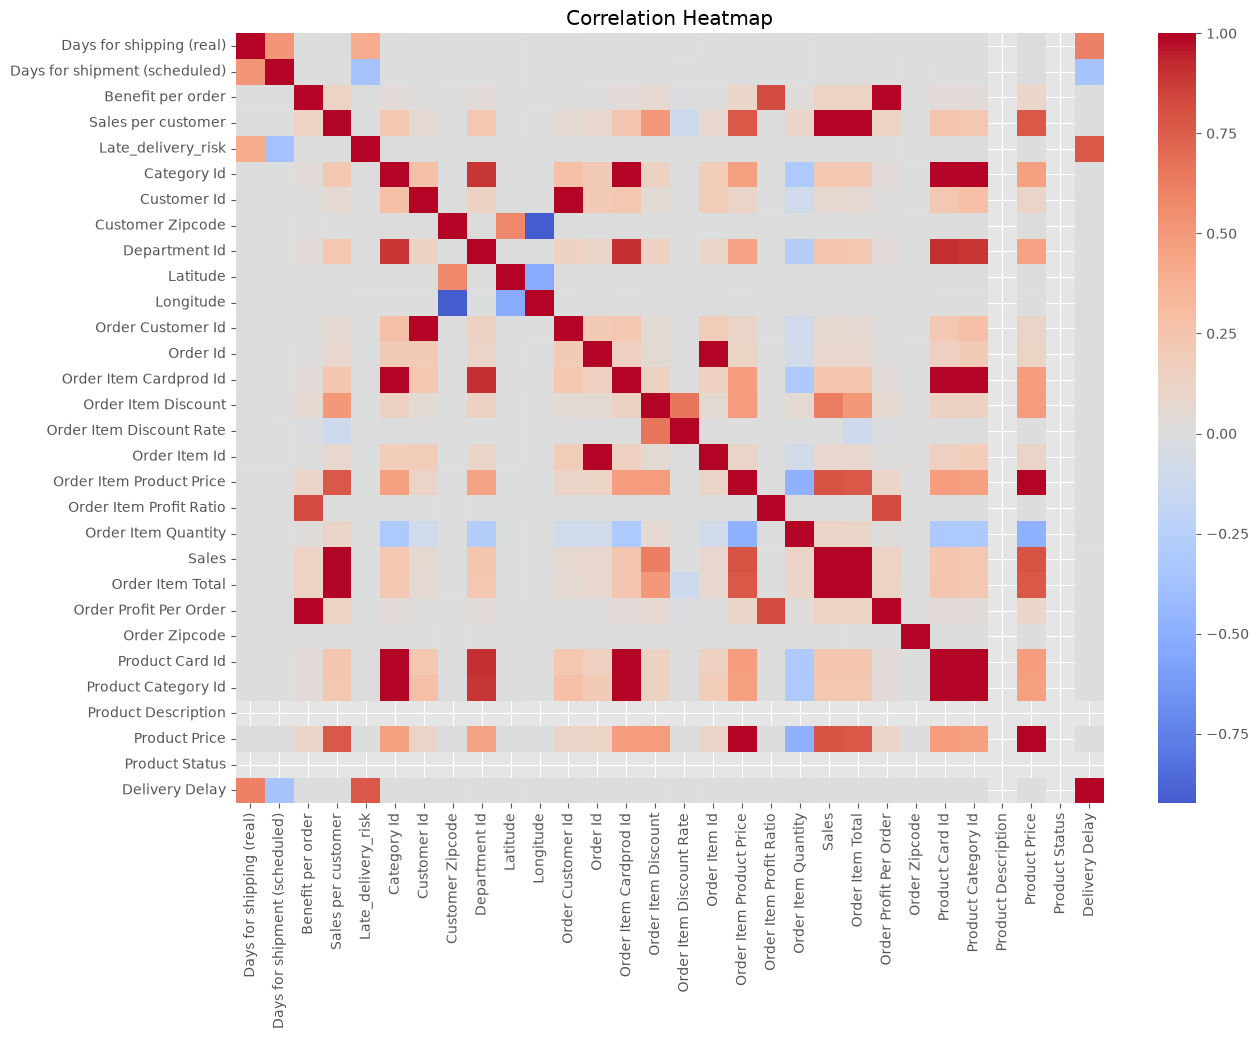

In [39]:
plt.figure(figsize=(14,10))

corr = df_clean.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [40]:
region_summary = (
    df_clean.groupby("Order Region")
    .agg(
        Orders=("Order Id", "nunique"),
        Revenue=("Sales", "sum"),
        Profit=("Benefit per order", "sum"),
        Avg_Delivery=("Days for shipping (real)", "mean"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean")
    )
)

region_summary["Late_Delivery_Rate"] *= 100

region_summary.sort_values(
    by="Late_Delivery_Rate",
    ascending=False
).head(15)

,Orders,Revenue,Profit,Avg_Delivery,Late_Delivery_Rate
Order Region,,,,,
Central Africa,556,3.272630e+05,33447.269960,3.560525,57.960644
South Asia,3335,1.553681e+06,165703.900124,3.502005,56.266977
East Africa,613,3.762349e+05,43167.729927,3.514579,55.939525
Western Europe,10010,5.894381e+06,625446.080548,3.498432,55.848611
South of USA,1345,7.857839e+05,88114.879898,3.492707,55.772559
Eastern Europe,1292,7.742666e+05,79717.049920,3.500765,55.663265
East of USA,2323,1.371112e+06,156263.300194,3.500940,55.661605
Southeast Asia,4356,1.932496e+06,211342.819786,3.496698,55.529930
Central Asia,184,1.098399e+05,13045.280051,3.417722,55.334539


In [41]:
shipping_summary = (
    df_clean.groupby("Shipping Mode")
    .agg(
        Orders=("Order Id", "nunique"),
        Avg_Delivery=("Days for shipping (real)", "mean"),
        Avg_Scheduled=("Days for shipment (scheduled)", "mean"),
        Late_Rate=("Late_delivery_risk", "mean"),
        Revenue=("Sales", "sum"),
        Profit=("Benefit per order", "sum")
    )
)

shipping_summary["Late_Rate"] *= 100

shipping_summary

,Orders,Avg_Delivery,Avg_Scheduled,Late_Rate,Revenue,Profit
Shipping Mode,,,,,,
First Class,10079,2.000000,1.0,95.322499,5.674370e+06,6.431219e+05
Same Day,3571,0.478279,0.0,45.743042,1.942529e+06,2.030184e+05
Second Class,12778,3.990828,2.0,76.632781,7.145445e+06,7.503082e+05
Standard Class,39324,3.995907,4.0,38.071683,2.202239e+07,2.370454e+06


In [42]:
customer_summary = (
    df_clean.groupby("Customer Segment")
    .agg(
        Customers=("Customer Id", "nunique"),
        Orders=("Order Id", "nunique"),
        Revenue=("Sales", "sum"),
        Profit=("Benefit per order", "sum"),
        Avg_Delivery=("Days for shipping (real)", "mean")
    )
)

customer_summary

,Customers,Orders,Revenue,Profit,Avg_Delivery
Customer Segment,,,,,
Consumer,10695,34119,1.909579e+07,2.073488e+06,3.497508
Corporate,6239,19856,1.116841e+07,1.202575e+06,3.489788
Home Office,3718,11777,6.520538e+06,6.908403e+05,3.511450


In [43]:
category_summary = (
    df_clean.groupby("Category Name")
    .agg(
        Orders=("Order Id", "nunique"),
        Revenue=("Sales", "sum"),
        Profit=("Benefit per order", "sum"),
        Avg_Delivery=("Days for shipping (real)", "mean"),
        Late_Rate=("Late_delivery_risk", "mean")
    )
)

category_summary["Late_Rate"] *= 100

category_summary.sort_values(
    by="Revenue",
    ascending=False
).head(15)

,Orders,Revenue,Profit,Avg_Delivery,Late_Rate
Category Name,,,,,
Fishing,15164,6.929654e+06,756220.767190,3.502049,54.926407
Cleats,20386,4.431943e+06,494636.919791,3.506578,54.971284
Camping & Hiking,12299,4.118426e+06,427455.568106,3.498215,54.534198
Cardio Equipment,11355,3.694843e+06,383011.098485,3.495235,54.496677
Women's Apparel,17869,3.147800e+06,350421.029567,3.484716,54.556691
Water Sports,13758,3.113845e+06,325146.960038,3.482754,54.806950
Men's Footwear,18783,2.891758e+06,311902.820214,3.501259,54.486200
Indoor/Outdoor Games,16623,2.888994e+06,318451.430554,3.495751,54.746606
Shop By Sport,10136,1.309522e+06,129813.960315,3.493627,55.152950


In [44]:
same_day = df_clean[df_clean["Shipping Mode"] == "Same Day"]

same_day_summary = (
    same_day.groupby("Order Region")
    .agg(
        Orders=("Order Id", "nunique"),
        Avg_Delivery=("Days for shipping (real)", "mean"),
        Late_Rate=("Late_delivery_risk", "mean"),
        Revenue=("Sales", "sum")
    )
)

same_day_summary["Late_Rate"] *= 100

same_day_summary.sort_values(
    by="Orders",
    ascending=False
)

,Orders,Avg_Delivery,Late_Rate,Revenue
Order Region,,,,
Western Europe,529,0.488963,47.357860,311344.875757
Central America,494,0.486999,45.748419,280530.265341
Oceania,282,0.421947,40.649150,122960.422333
South America,264,0.541237,51.288660,151776.343041
Northern Europe,208,0.423598,39.845261,114352.061942
Southeast Asia,208,0.421286,40.798226,88637.611571
Southern Europe,207,0.574692,53.251318,120445.882345
Eastern Asia,182,0.485222,47.536946,79838.451523
South Asia,174,0.517150,49.604222,70126.351362


In [45]:
readiness = region_summary.copy()

readiness["Revenue_Score"] = (
    readiness["Revenue"] /
    readiness["Revenue"].max()
)

readiness["Delivery_Score"] = (
    1 -
    readiness["Late_Delivery_Rate"] /
    100
)

readiness["Readiness Score"] = (
    0.6 * readiness["Revenue_Score"] +
    0.4 * readiness["Delivery_Score"]
)

readiness.sort_values(
    by="Readiness Score",
    ascending=False
)

,Orders,Revenue,Profit,Avg_Delivery,Late_Delivery_Rate,Revenue_Score,Delivery_Score,Readiness Score
Order Region,,,,,,,,
Western Europe,10010,5.894381e+06,625446.080548,3.498432,55.848611,1.000000,0.441514,0.776606
Central America,9396,5.665712e+06,616341.570651,3.510462,54.754596,0.961206,0.452454,0.757705
South America,4979,2.960881e+06,335154.400817,3.505725,54.308671,0.502323,0.456913,0.484159
Northern Europe,3716,2.155831e+06,233450.600647,3.502349,54.044118,0.365743,0.459559,0.403270
Southern Europe,3543,2.047919e+06,230829.229883,3.435797,54.384477,0.347436,0.456155,0.390924
Oceania,4362,2.016654e+06,201478.020484,3.496354,54.020497,0.342132,0.459795,0.389197
Southeast Asia,4356,1.932496e+06,211342.819786,3.496698,55.529930,0.327854,0.444701,0.374593
Caribbean,2806,1.651019e+06,171825.640024,3.507213,53.077663,0.280101,0.469223,0.355750
West of USA,2667,1.571416e+06,164940.660455,3.504942,53.959715,0.266596,0.460403,0.344118


In [46]:
features = [
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Category Name",
    "Customer Segment",
    "Market",
    "Order Region",
    "Shipping Mode",
    "Order Item Quantity",
    "Product Price"
]

target = "Late_delivery_risk"

X = df_clean[features]
y = df_clean[target]

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()

numerical = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer([
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical
    ),
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]),
        numerical
    )
])

In [51]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])